# importing libraries

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import numpy as np
from sqlalchemy import create_engine
import pyodbc
from scipy import stats

In [ ]:
#adjusting pandas display settings to show the full dataframe without truncation

# 1. Prevent the "split" into two parts when df is too wide
pd.set_option('display.expand_frame_repr', False)

# 2. Ensure all columns are shown (don't hide them with '...')
pd.set_option('display.max_columns', None)

# 3. Optional: Set a specific width if the lines are still breaking
pd.set_option('display.width', 1000)

#  Loading the data using pandas in python to reduce extra work troubleshooting source csv table mismatch with target table

In [ ]:
df = pd.read_csv(r'I:\SQL Data\Dataco project\DataCoSupplyChainDataset.csv',
    encoding='latin-1',
    quotechar='"',
    on_bad_lines='skip'
)

In [ ]:
engine = create_engine(
    r'mssql+pyodbc:///Datacodb'
    r'?driver=ODBC+Driver+17+for+SQL+Server'
    r'&trusted_connection=yes'
    r'&Encrypt=no'
)

In [ ]:
# loading the dataframe into the SQL server database, replacing the existing table if it already exists
df.to_sql(
    'dataco_staging',
    engine,
    if_exists='replace',
    index=False,
    chunksize=5000
)

-37

In [ ]:
# connecting to the SQL server database using pyodbc for direct querying
conn = pyodbc.connect(
    'DRIVER={ODBC Driver 17 for SQL Server};'
    'SERVER=#(your_server_name)#;'
    'DATABASE=datacodb;'
    'Trusted_Connection=yes;'
    'Encrypt=no;'
    'TrustServerCertificate=yes;'
)


# Cleaning phase

# checking data quality & correlation logic

In [ ]:
# creating the engine function to summarize the data health of the df

def data_health_summary(dataframe):
    report = pd.DataFrame({
        'Data Type': dataframe.dtypes,
        'Missing Values': dataframe.isnull().sum(),
        'missing Value Percentage': (dataframe.isnull().sum() / len(dataframe)) * 100,
        'unique Values': dataframe.nunique(),
        'unique sample Values': dataframe.apply(lambda x: x.dropna().unique()[:5]),
    })
    return report.sort_values(by='missing Value Percentage', ascending=False)

In [4]:
data_health_summary(df)

# key insights from data health summary
# 1. te columns of Order Zipcode and Product Description have a high value of missing data and missing value percentage. This could impact any analysis that relies on these columns, so we may need to drop these columns
# 2. the column of Order Item Id has unique values for each row, so this could be used as a unique identifier for each order item. this is the primary key for the fact table of our shipments table
# 3. the columns of (Customer Email, Customer password, Product Image,Product Status) have dummy values, so we can drop these columns as they do not provide any useful information for our analysis
# 4. The columns of ('order profit per order' and 'Benefit per order' are the same values along all the dataset)


,Data Type,Missing Values,missing Value Percentage,unique Values,unique sample Values
Customer Lname,object,8,0.004432,1109,"[Malone, Rodriguez, Wilson, Henry, Smith]"
Customer Zipcode,float64,3,0.001662,995,"[28601.0, 60625.0, 78240.0, 725.0, 33161.0]"
Type,object,0,0.000000,4,"[CASH, PAYMENT, DEBIT, TRANSFER]"
Product Price,float64,0,0.000000,75,"[299.980011, 199.9900055, 50.0, 129.9900055, 2..."
Order Item Id,int64,0,0.000000,180519,"[1, 2, 3, 4, 5]"
Order Item Profit Ratio,float64,0,0.000000,162,"[0.37, 0.47, 0.3, 0.34, 0.1]"
Order Item Quantity,int64,0,0.000000,5,"[1, 5, 2, 3, 4]"
Sales,float64,0,0.000000,193,"[299.98, 199.99, 250.0, 129.99, 49.98]"
Order Item Total,float64,0,0.000000,2927,"[239.98, 193.99, 227.5, 107.89, 40.98]"
Order Profit Per Order,float64,0,0.000000,21998,"[88.79, 91.18, 68.25, 36.47, 4.1]"


In [ ]:
df.head(100)


,Type,Days for shipping (real),Days for shipment (scheduled),Benefit per order,Sales per customer,Delivery Status,Late_delivery_indicator,Category Id,Category Name,Customer City,...,Order Status,Product Card Id,Product Category Id,Product Name,Product Price,shipping date (DateOrders),Shipping Mode,Delay Time (Days),custom severity score,State_Segment
0,CASH,2,4,88.790001,239.979996,Advance shipping,0,43,Camping & Hiking,Hickory,...,CLOSED,957,43,Diamondback Women's Serene Classic Comfort Bi,299.980011,1/3/2015 0:00,Standard Class,0,0.0000,Star_State
1,PAYMENT,3,4,91.180000,193.990005,Advance shipping,0,48,Water Sports,Chicago,...,PENDING_PAYMENT,1073,48,Pelican Sunstream 100 Kayak,199.990005,1/4/2015 0:21,Standard Class,0,0.0000,Under_Performing
2,PAYMENT,3,4,68.250000,227.500000,Advance shipping,0,24,Women's Apparel,Chicago,...,PENDING_PAYMENT,502,24,Nike Men's Dri-FIT Victory Golf Polo,50.000000,1/4/2015 0:21,Standard Class,0,0.0000,Under_Performing
3,PAYMENT,3,4,36.470001,107.889999,Advance shipping,0,18,Men's Footwear,Chicago,...,PENDING_PAYMENT,403,18,Nike Men's CJ Elite 2 TD Football Cleat,129.990005,1/4/2015 0:21,Standard Class,0,0.0000,Under_Performing
4,CASH,5,4,4.100000,40.980000,Late delivery,1,40,Accessories,San Antonio,...,CLOSED,897,40,Team Golf New England Patriots Putter Grip,24.990000,1/6/2015 1:03,Standard Class,1,1.7183,Under_Performing
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,TRANSFER,2,2,1.180000,91.000000,Shipping on time,0,24,Women's Apparel,Caguas,...,PENDING,502,24,Nike Men's Dri-FIT Victory Golf Polo,50.000000,1/3/2015 12:15,Second Class,0,0.0000,Star_State
96,TRANSFER,2,2,-3.970000,283.480011,Shipping on time,0,43,Camping & Hiking,Caguas,...,PENDING,957,43,Diamondback Women's Serene Classic Comfort Bi,299.980011,1/3/2015 12:15,Second Class,0,0.0000,Star_State
97,TRANSFER,2,2,176.389999,359.980011,Shipping on time,0,45,Fishing,Caguas,...,PENDING,1004,45,Field & Stream Sportsman 16 Gun Fire Safe,399.980011,1/3/2015 12:15,Second Class,0,0.0000,Star_State
98,CASH,3,2,13.940000,49.790001,Late delivery,1,17,Cleats,Cordova,...,CLOSED,365,17,Perfect Fitness Perfect Rip Deck,59.990002,1/4/2015 12:36,Second Class,1,1.7183,Star_State


In [ ]:
Transportation =df[['Late_delivery_risk','Order Item Total','Order Item Quantity','Days for shipment (scheduled)','Days for shipping (real)']].corr()
Financial = df[['Order Profit Per Order','Order Item Discount Rate','Sales', 'Product Price']].corr()

Text(0.5, 1.0, 'Correlation Heatmap')

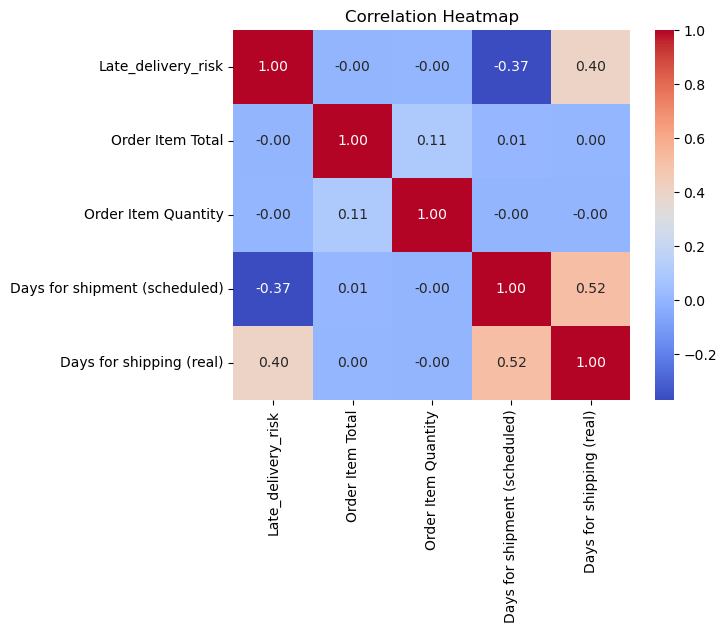

In [ ]:
sns.heatmap(Transportation, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap')

Text(0.5, 1.0, 'Correlation Heatmap')

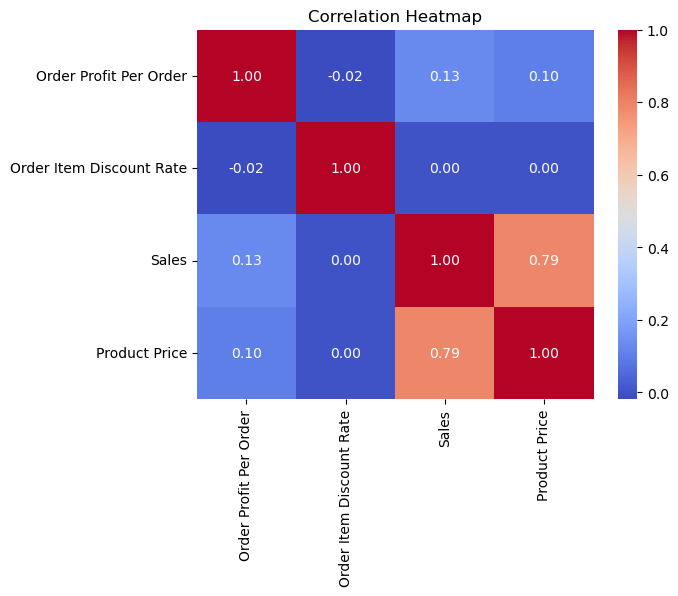

In [10]:
sns.heatmap(Financial, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap')

## defining outliers using IQR method

In [ ]:
# detecting outliers in the columns of sales, order profit per order, and delay time (days) using the IQR method

def detect_outliers(column_name):
    target_column = pd.to_numeric(df[column_name], errors='coerce').dropna()

    Q1 = target_column.quantile(0.25)
    Q3 = target_column.quantile(0.75)
    IQR = Q3 - Q1
    lower_limit = Q1 - 1.5 * IQR
    upper_limit = Q3 + 1.5 * IQR
    outliers = target_column[(target_column < lower_limit) | (target_column > upper_limit)]

    print(f'=== {target_column.name} ===')
    print(f'Q1: {Q1:.2f} | Q3: {Q3:.2f} | IQR: {IQR:.2f}')
    print(f'Lower limit: {lower_limit:.2f} | Upper limit: {upper_limit:.2f}')
    print(f'Outliers count: {len(outliers):,} | Outliers %: {(len(outliers)/len(target_column)*100):.1f}%')
    print()

detect_outliers('Sales')
detect_outliers('Order Profit Per Order')
detect_outliers('Delay Time (Days)')

=== Sales ===
Q1: 119.98 | Q3: 299.95 | IQR: 179.97
Lower limit: -149.97 | Upper limit: 569.90
Outliers count: 488 | Outliers %: 0.3%

=== Order Profit Per Order ===
Q1: 7.00 | Q3: 64.80 | IQR: 57.80
Lower limit: -79.70 | Upper limit: 151.50
Outliers count: 18,942 | Outliers %: 10.5%

=== Delay Time (Days) ===
Q1: 0.00 | Q3: 1.00 | IQR: 1.00
Lower limit: -1.50 | Upper limit: 2.50
Outliers count: 13,469 | Outliers %: 7.5%



In [52]:
profit = pd.to_numeric(df['Order Profit Per Order'], errors='coerce').dropna()
profit_outliers = profit[(profit < -79.70) | (profit > 151.50)]
print(f"Loss outliers (below -$79.70): {(profit_outliers < 0).sum():,}")
print(f"Gain outliers (above $151.50): {(profit_outliers > 0).sum():,}")
print(f"Average loss outlier: ${profit_outliers[profit_outliers < 0].mean():.2f}")
print(f"Average gain outlier: ${profit_outliers[profit_outliers > 0].mean():.2f}")

Loss outliers (below -$79.70): 13,727
Gain outliers (above $151.50): 5,215
Average loss outlier: $-239.24
Average gain outlier: $195.12


In [ ]:
# financial outlier analysis after dropping non financial relevant records

excluded_status = ['CANCELED', 'SUSPECTED_FRAUD', 'PAYMENT_REVIEW']
df_filtered = df[~df['Order Status'].isin(excluded_status)].copy()

# 2. Target the actual Profit column
Targeted_column_a = df_filtered['Order Profit Per Order'].dropna()


Q1_a = Targeted_column_a.quantile(0.25)
Q3_a = Targeted_column_a.quantile(0.75)
IQR_a = Q3_a - Q1_a

lower_limit_a = Q1_a - 1.5 * IQR_a
upper_limit_a = Q3_a + 1.5 * IQR_a

# 4. Count the actual outliers
lower_outliers_a = Targeted_column_a[Targeted_column_a < lower_limit_a]
upper_outliers_a = Targeted_column_a[Targeted_column_a > upper_limit_a]
total_outlier_a = len(lower_outliers_a) + len(upper_outliers_a)

print('=== Adjusted Profit Outlier Analysis ===')
print(f'Q1: {Q1_a:.2f} | Q3: {Q3_a:.2f} | IQR: {IQR_a:.2f}')
print(f'Lower Limit: {lower_limit_a:.2f} | Upper Limit: {upper_limit_a:.2f}')
print(f'Total outliers: {total_outlier_a:,}')
print(f'Lower Outlier Count: {len(lower_outliers_a):,} | Upper Outlier Count: {len(upper_outliers_a):,}')
print(f'Outlier %: {100*total_outlier_a/len(Targeted_column_a):.1f} %')
print('=== In financial terms that means ===')
print(f'Total_loss_damage = {lower_outliers_a.sum():,}')
print(f'Total_benefit_gain = {upper_outliers_a.sum():,}')
print(f'Net outlier_impact = {(upper_outliers_a.sum()+lower_outliers_a.sum()):,}')

=== Adjusted Profit Outlier Analysis ===
Q1: 7.03 | Q3: 64.80 | IQR: 57.77
Lower Limit: -79.62 | Upper Limit: 151.45
Total outliers: 17,922
Lower Outlier Count: 12,982 | Upper Outlier Count: 4,940
Outlier %: 10.5 %
=== In financial terms that means ===
Total_loss_damage = -3,103,723.36
Total_benefit_gain = 963,745.03
Net outlier_impact = -2,139,978.33


# actual VS scheduled lead time histogram

Text(0, 0.5, 'Frequency')

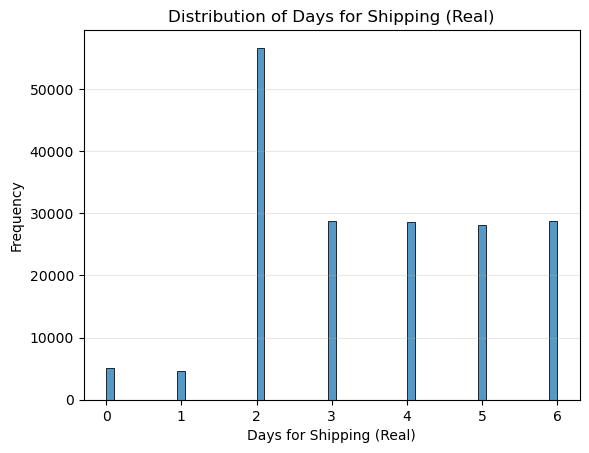

In [10]:
sns.histplot(df['Days for shipping (real)'])
plt.title('Distribution of Days for Shipping (Real)')
plt.xlabel('Days for Shipping (Real)')
plt.grid(axis='y', alpha=0.3)
plt.ylabel('Frequency')

Text(0, 0.5, 'Frequency')

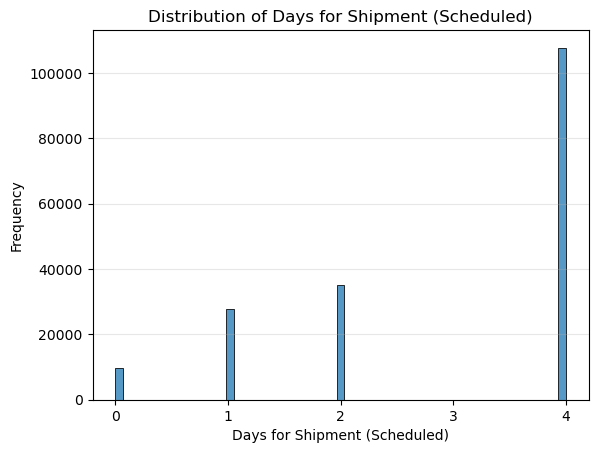

In [ ]:
sns.histplot(df['Days for shipment (scheduled)'])
plt.xticks(range(int(df['Days for shipment (scheduled)'].max()) + 1))
plt.title('Distribution of Days for Shipment (Scheduled)')
plt.xlabel('Days for Shipment (Scheduled)')
plt.grid(axis='y', alpha=0.3)
plt.ylabel('Frequency')

# although ~30K of orders are promised to be delivered within 3 days, about 0 orders are actually delivered in this time frame

# State segmentation (approach: Pareto analysis)

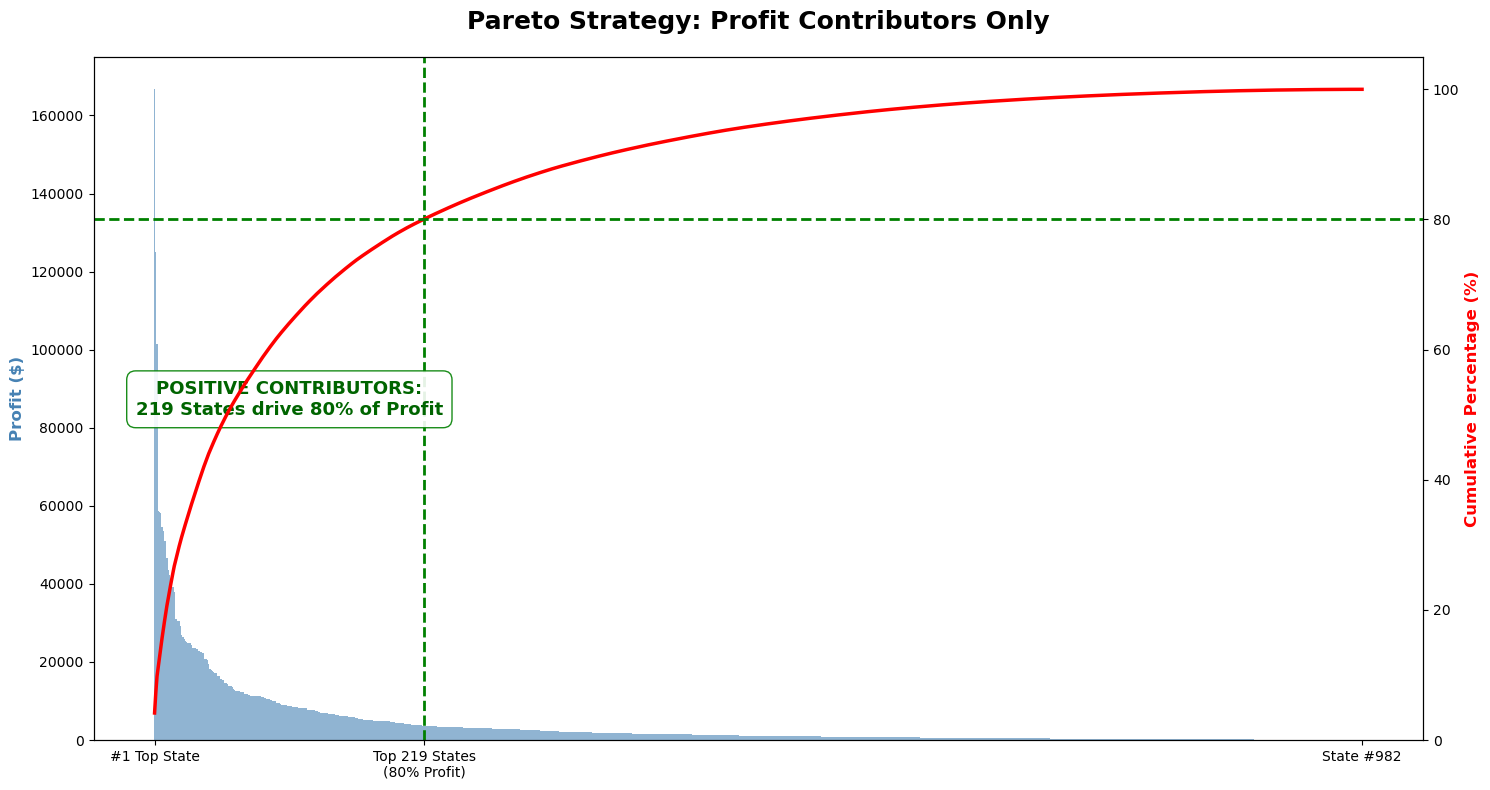

In [ ]:
# 1. AGGREGATE: Group and rename
df_pareto = df.groupby('Order State')['Order Profit Per Order'].sum().reset_index()
df_pareto.columns = ['State', 'Profit']

# 2. FILTER: Keep only the states that contributed POSITIVE profit
# This ensures our cumulative line moves only UP
df_pareto = df_pareto[df_pareto['Profit'] > 0]

# 3. SORT: Must be done before cumulative sum
df_pareto = df_pareto.sort_values(by='Profit', ascending=False).reset_index(drop=True)

# 4. CALCULATE: Cumulative sum and percentage
df_pareto['Cum_sum'] = df_pareto['Profit'].cumsum()
total_positive_profit = df_pareto['Profit'].sum()
df_pareto['cum_pct'] = (df_pareto['Cum_sum'] / total_positive_profit) * 100

# 5. IDENTIFY: Finding the 80% point of POSITIVE contributors
cutoff_idx = df_pareto[df_pareto['cum_pct'] >= 80].index[0]
total_positive_states = len(df_pareto)

# 6. VISUALIZE: The Executive Chart
fig, ax1 = plt.subplots(figsize=(15, 8))

# Bars
ax1.bar(range(total_positive_states), df_pareto['Profit'], color='steelblue', alpha=0.6, width=1.0)
ax1.set_ylabel('Profit ($)', color='steelblue', fontsize=12, fontweight='bold')

# Line
ax2 = ax1.twinx()
ax2.plot(range(total_positive_states), df_pareto['cum_pct'], color='red', linewidth=2.5)
ax2.set_ylabel('Cumulative Percentage (%)', color='red', fontsize=12, fontweight='bold')

# Intersection lines
ax2.axhline(80, color='green', linestyle='--', linewidth=2)
ax1.axvline(cutoff_idx, color='green', linestyle='--', linewidth=2)

# Clean labels
ax1.set_xticks([0, cutoff_idx, total_positive_states - 1])
ax1.set_xticklabels(['#1 Top State', f'Top {cutoff_idx} States\n(80% Profit)', f'State #{total_positive_states}'])
ax2.set_ylim(0, 105)

# Insight box
ax1.annotate(f'POSITIVE CONTRIBUTORS:\n{cutoff_idx} States drive 80% of Profit',
            xy=(cutoff_idx/2, df_pareto['Profit'].max()/2),
            ha='center', fontsize=13, fontweight='bold', color='darkgreen',
            bbox=dict(boxstyle="round,pad=0.5", fc="white", ec="green", alpha=0.9))

plt.title('Pareto Strategy: Profit Contributors Only', fontsize=18, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

# Further correlation analysis 

## Financial correlation analysis

In [3]:
df_correlation = df[[
    'Sales per customer',
    'Order Item Discount', 'Order Item Discount Rate',
    'Order Item Quantity', 'Sales', 'Order Item Total',
    'Order Profit Per Order',
    'custom severity score'
]]
df_correlation

,Sales per customer,Order Item Discount,Order Item Discount Rate,Order Item Quantity,Sales,Order Item Total,Order Profit Per Order,custom severity score
0,239.979996,60.00,0.20,1,299.98,239.98,88.79,0.0000
1,193.990005,6.00,0.03,1,199.99,193.99,91.18,0.0000
2,227.500000,22.50,0.09,5,250.00,227.50,68.25,0.0000
3,107.889999,22.10,0.17,1,129.99,107.89,36.47,0.0000
4,40.980000,9.00,0.18,2,49.98,40.98,4.10,1.7183
...,...,...,...,...,...,...,...,...
180514,161.869995,53.96,0.25,1,215.82,161.87,-107.96,6.3891
180515,172.660004,43.16,0.20,1,215.82,172.66,-126.56,0.0000
180516,314.640015,13.11,0.04,1,327.75,314.64,91.25,0.0000
180517,10.910000,0.63,0.06,1,11.54,10.91,1.53,0.0000


In [4]:
corr_matrix = df_correlation.corr()
corr_matrix

,Sales per customer,Order Item Discount,Order Item Discount Rate,Order Item Quantity,Sales,Order Item Total,Order Profit Per Order,custom severity score
Sales per customer,1.000000,0.498734,-0.119469,0.105413,0.989744,1.000000,0.133484,-0.001044
Order Item Discount,0.498734,1.000000,0.659955,0.065379,0.617438,0.498734,0.064756,0.001694
Order Item Discount Rate,-0.119469,0.659955,1.000000,-0.000028,0.000346,-0.119469,-0.018644,0.003451
Order Item Quantity,0.105413,0.065379,-0.000028,1.000000,0.106442,0.105413,0.015696,0.003580
Sales,0.989744,0.617438,0.000346,0.106442,1.000000,0.989744,0.131816,-0.000668
Order Item Total,1.000000,0.498734,-0.119469,0.105413,0.989744,1.000000,0.133484,-0.001044
Order Profit Per Order,0.133484,0.064756,-0.018644,0.015696,0.131816,0.133484,1.000000,-0.003083
custom severity score,-0.001044,0.001694,0.003451,0.003580,-0.000668,-0.001044,-0.003083,1.000000


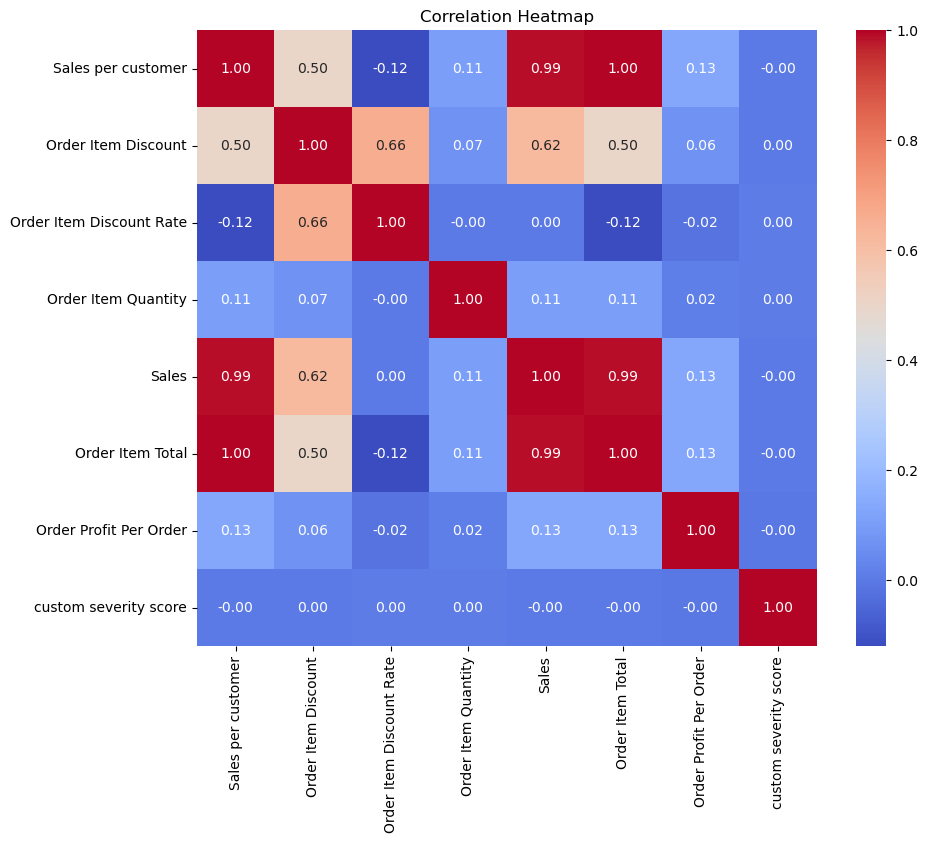

In [5]:
corr_matrix = df_correlation.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap')
plt.show()

## category corelation analysis

C:\Users\Ali_Elsharkawy\AppData\Local\Temp\ipykernel_15912\3072632418.py:15: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_time = pd.read_sql(query, conn)


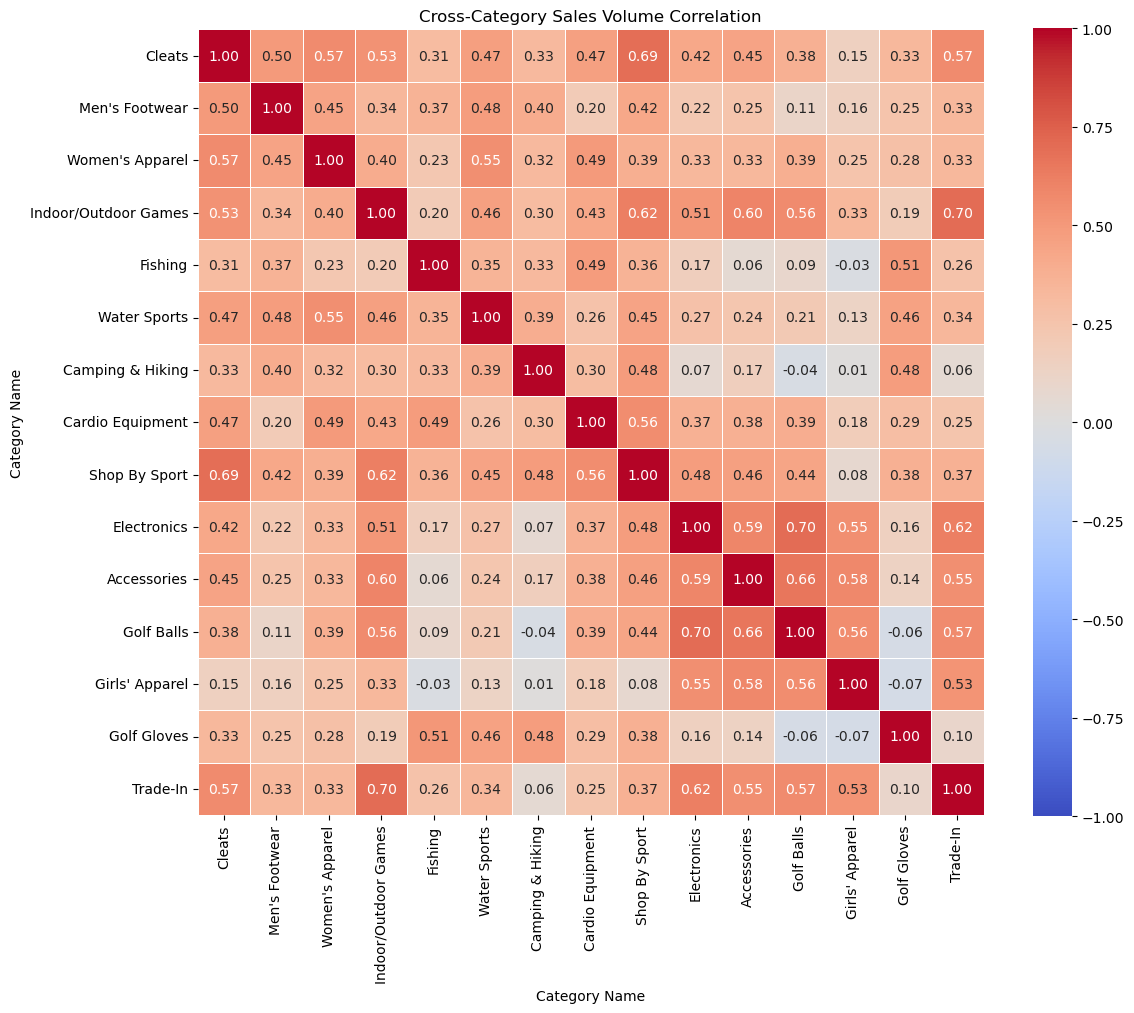

In [5]:
query = """
SELECT
    DATEPART(MONTH, TRY_CAST([order date (DateOrders)] AS DATE)) AS order_month,
    DATEPART(YEAR, TRY_CAST([order date (DateOrders)] AS DATE)) AS order_year,
    [Category Name],
    COUNT(*) AS order_count,
    SUM(CAST(Sales AS FLOAT)) AS total_sales
FROM dataco_clean
GROUP BY
    DATEPART(MONTH, TRY_CAST([order date (DateOrders)] AS DATE)),
    DATEPART(YEAR, TRY_CAST([order date (DateOrders)] AS DATE)),
    [Category Name]
"""

df_time = pd.read_sql(query, conn)

# Pivot to get categories as columns, months as rows
df_pivot = df_time.pivot_table(
    index=['order_year', 'order_month'],
    columns='Category Name',
    values='order_count',
    aggfunc='sum'
).fillna(0)

# Focus on top 15 categories by total volume
top_categories = df_time.groupby('Category Name')['order_count']\
                        .sum()\
                        .nlargest(15)\
                        .index

df_top = df_pivot[top_categories]

# Correlation matrix between categories
cat_corr = df_top.corr(method='spearman')

# Plot
plt.figure(figsize=(12, 10))
sns.heatmap(
    cat_corr,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    vmin=-1, vmax=1,
    linewidths=0.5,
    square=True
)
plt.title('Cross-Category Sales Volume Correlation')
plt.tight_layout()
plt.show()

In [5]:
threshold = 0.50

# Reset the column name before unstacking
corr_renamed = cat_corr.copy()
corr_renamed.index.name = 'Category_A'
corr_renamed.columns.name = 'Category_B'

# Now unstack works cleanly
corr_pairs = corr_renamed.unstack().reset_index()
corr_pairs.columns = ['Category_A', 'Category_B', 'correlation']

# Remove self-correlations and duplicate mirror pairs
corr_pairs = corr_pairs[
    (corr_pairs['Category_A'] != corr_pairs['Category_B']) &
    (corr_pairs['Category_A'] < corr_pairs['Category_B'])
]

# Filter by threshold
strong_positive = corr_pairs[corr_pairs['correlation'] >= threshold]\
                    .sort_values('correlation', ascending=False)
strong_negative = corr_pairs[corr_pairs['correlation'] <= -threshold]\
                    .sort_values('correlation')

print(f"=== Strong Positive Correlations (>= {threshold}) ===")
print(strong_positive.to_string(index=False))

print(f"\n=== Strong Negative Correlations (<= -{threshold}) ===")
if len(strong_negative) == 0:
    print(f"None found at threshold {threshold}")
else:
    print(strong_negative.to_string(index=False))

=== Strong Positive Correlations (>= 0.5) ===
          Category_A           Category_B  correlation
Indoor/Outdoor Games             Trade-In     0.702791
         Electronics           Golf Balls     0.702384
              Cleats        Shop By Sport     0.691198
         Accessories           Golf Balls     0.661469
Indoor/Outdoor Games        Shop By Sport     0.623643
         Electronics             Trade-In     0.620795
         Accessories Indoor/Outdoor Games     0.599945
         Accessories          Electronics     0.586705
         Accessories       Girls' Apparel     0.579040
          Golf Balls             Trade-In     0.567962
              Cleats             Trade-In     0.565566
              Cleats      Women's Apparel     0.565537
          Golf Balls Indoor/Outdoor Games     0.562933
    Cardio Equipment        Shop By Sport     0.560522
      Girls' Apparel           Golf Balls     0.557390
        Water Sports      Women's Apparel     0.549333
         Electronic

In [9]:
strong_positive.to_sql(
    'category_correlations_strong',  # table name in SQL Server
    engine,
    if_exists='replace',             # drops and recreates if already exists
    index=False,                     # don't save pandas row numbers
    schema='dbo'                     # default SQL Server schema
)

print(f"Saved {len(strong_positive)} strong correlation pairs to SQL Server")

# Verify it landed correctly
verification = pd.read_sql(
    "SELECT * FROM category_correlations_strong ORDER BY correlation DESC",
    engine
)
print(verification)

Saved 22 strong correlation pairs to SQL Server
              Category_A            Category_B  correlation
0   Indoor/Outdoor Games              Trade-In     0.702791
1            Electronics            Golf Balls     0.702384
2                 Cleats         Shop By Sport     0.691198
3            Accessories            Golf Balls     0.661469
4   Indoor/Outdoor Games         Shop By Sport     0.623643
5            Electronics              Trade-In     0.620795
6            Accessories  Indoor/Outdoor Games     0.599945
7            Accessories           Electronics     0.586705
8            Accessories        Girls' Apparel     0.579040
9             Golf Balls              Trade-In     0.567962
10                Cleats              Trade-In     0.565566
11                Cleats       Women's Apparel     0.565537
12            Golf Balls  Indoor/Outdoor Games     0.562933
13      Cardio Equipment         Shop By Sport     0.560522
14        Girls' Apparel            Golf Balls     0

# Top 10 categories sales over data time frame

C:\Users\Ali_Elsharkawy\AppData\Local\Temp\ipykernel_12944\198747138.py:23: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_time2 = pd.read_sql(query2, conn)


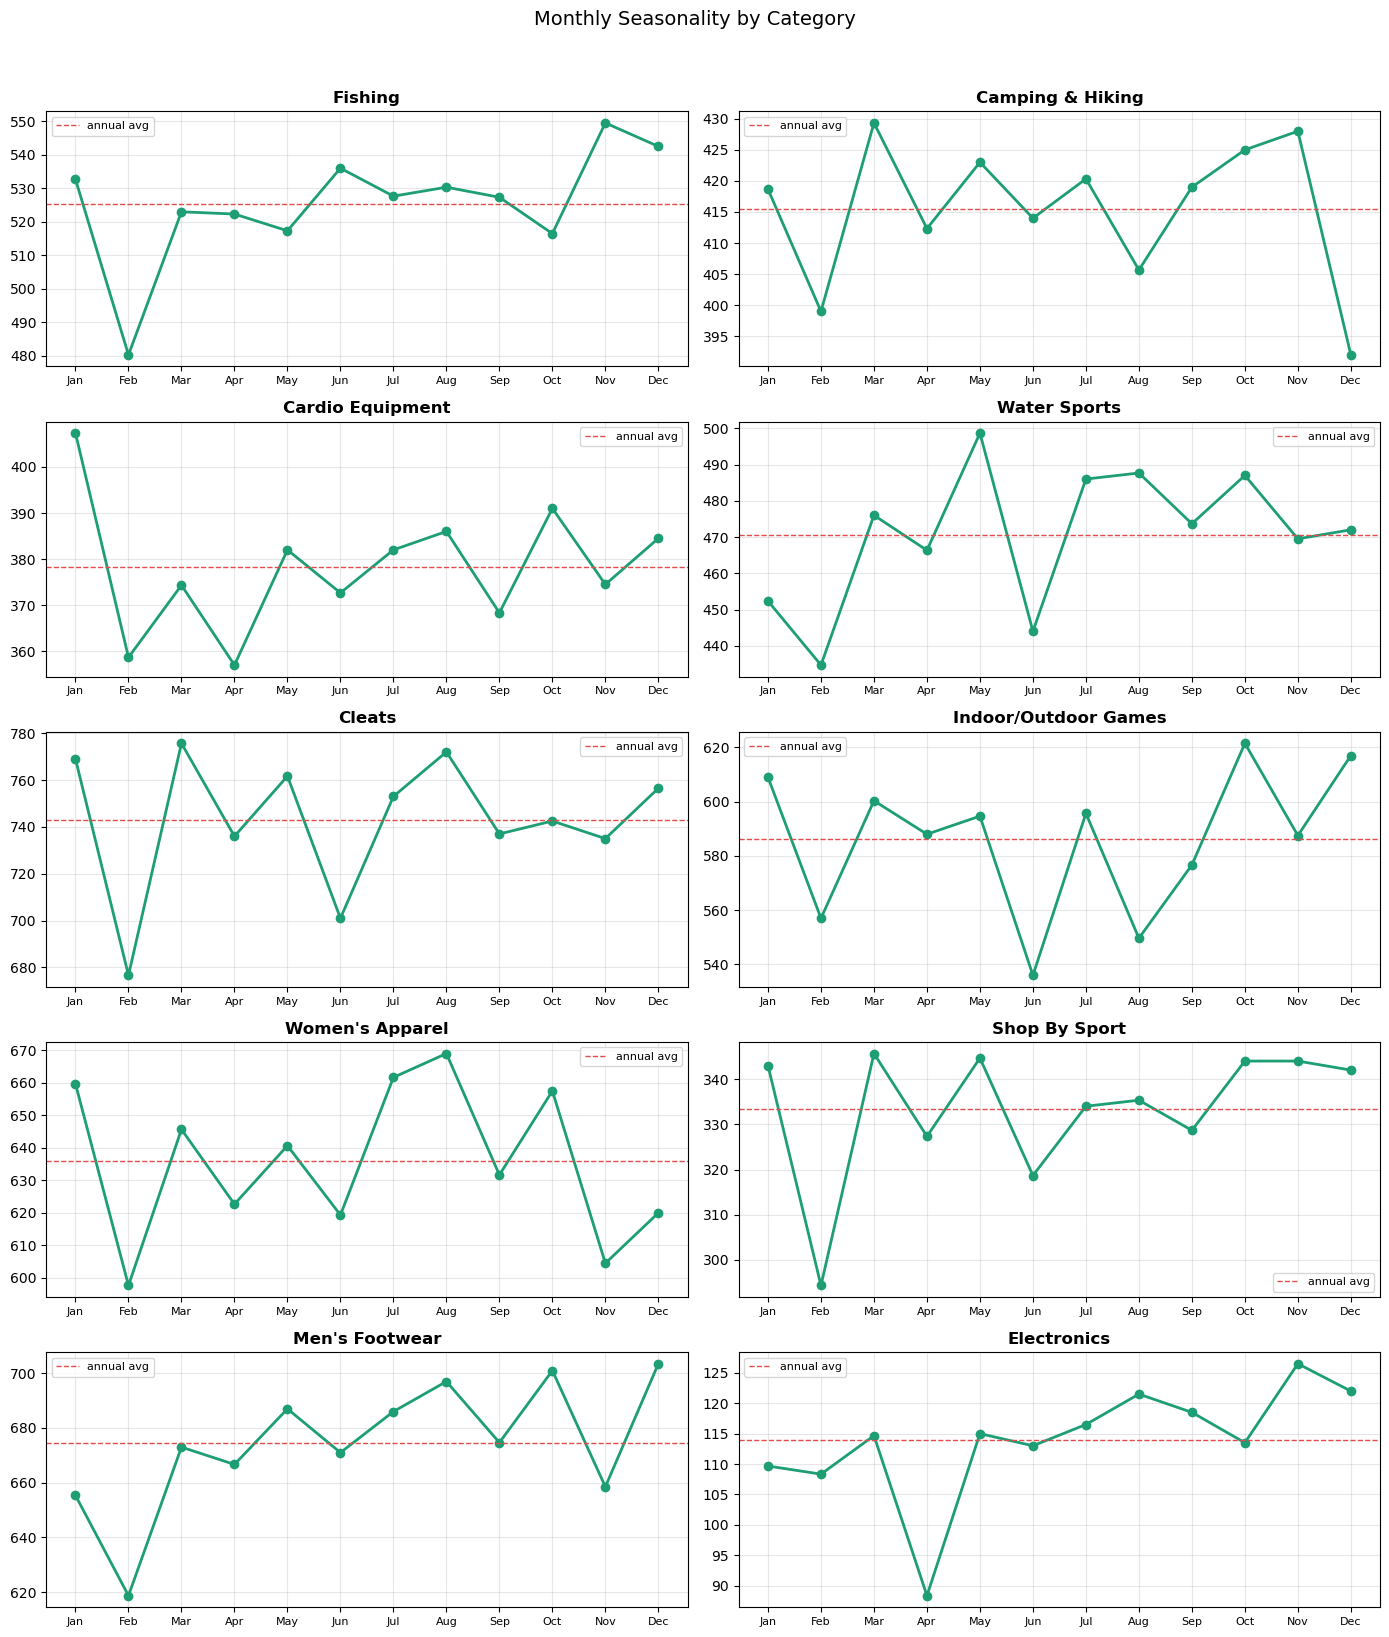

In [ ]:
# Focus on top 10 money generating products
categories_of_interest = [
    'Fishing', 'Camping & Hiking', 'Cardio Equipment',
    'Water Sports', 'Cleats', 'Indoor/Outdoor Games',
    'Women\'s Apparel', 'Shop By Sport','Men\'s Footwear','Electronics'
]
query2 = """
SELECT
    DATEPART(MONTH, TRY_CAST([order date (DateOrders)] AS DATE)) AS order_month,
    DATEPART(YEAR, TRY_CAST([order date (DateOrders)] AS DATE)) AS order_year,
    [Category Name],
    COUNT(*) AS order_count,
    SUM(CAST(Sales AS FLOAT)) AS total_sales
FROM dataco_clean
where  TRY_CAST([order date (DateOrders)] AS DATE) < '2017-10-01'
GROUP BY
    DATEPART(MONTH, TRY_CAST([order date (DateOrders)] AS DATE)),
    DATEPART(YEAR, TRY_CAST([order date (DateOrders)] AS DATE)),
    [Category Name]
"""


df_time2 = pd.read_sql(query2, conn)
df_seasonal = df_time2[df_time2['Category Name'].isin(categories_of_interest)]

# Monthly average across all years
monthly_avg = df_seasonal.groupby(
    ['Category Name', 'order_month']
)['order_count'].mean().reset_index()

# Plot seasonality lines
fig, axes = plt.subplots(5, 2, figsize=(14, 16))
axes = axes.flatten()

month_labels = ['Jan','Feb','Mar','Apr','May','Jun',
                'Jul','Aug','Sep','Oct','Nov','Dec']

for i, category in enumerate(categories_of_interest):
    cat_data = monthly_avg[monthly_avg['Category Name'] == category]\
                .sort_values('order_month')

    axes[i].plot(
        cat_data['order_month'],
        cat_data['order_count'],
        marker='o',
        linewidth=2,
        color='#1D9E75'
    )
    axes[i].set_title(category, fontsize=12, fontweight='bold')
    axes[i].set_xticks(range(1, 13))
    axes[i].set_xticklabels(month_labels, fontsize=8)
    axes[i].axhline(
        y=cat_data['order_count'].mean(),
        color='#E24B4A',
        linestyle='--',
        linewidth=1,
        label='annual avg'
    )
    axes[i].legend(fontsize=8)
    axes[i].grid(True, alpha=0.3)

plt.suptitle('Monthly Seasonality by Category', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

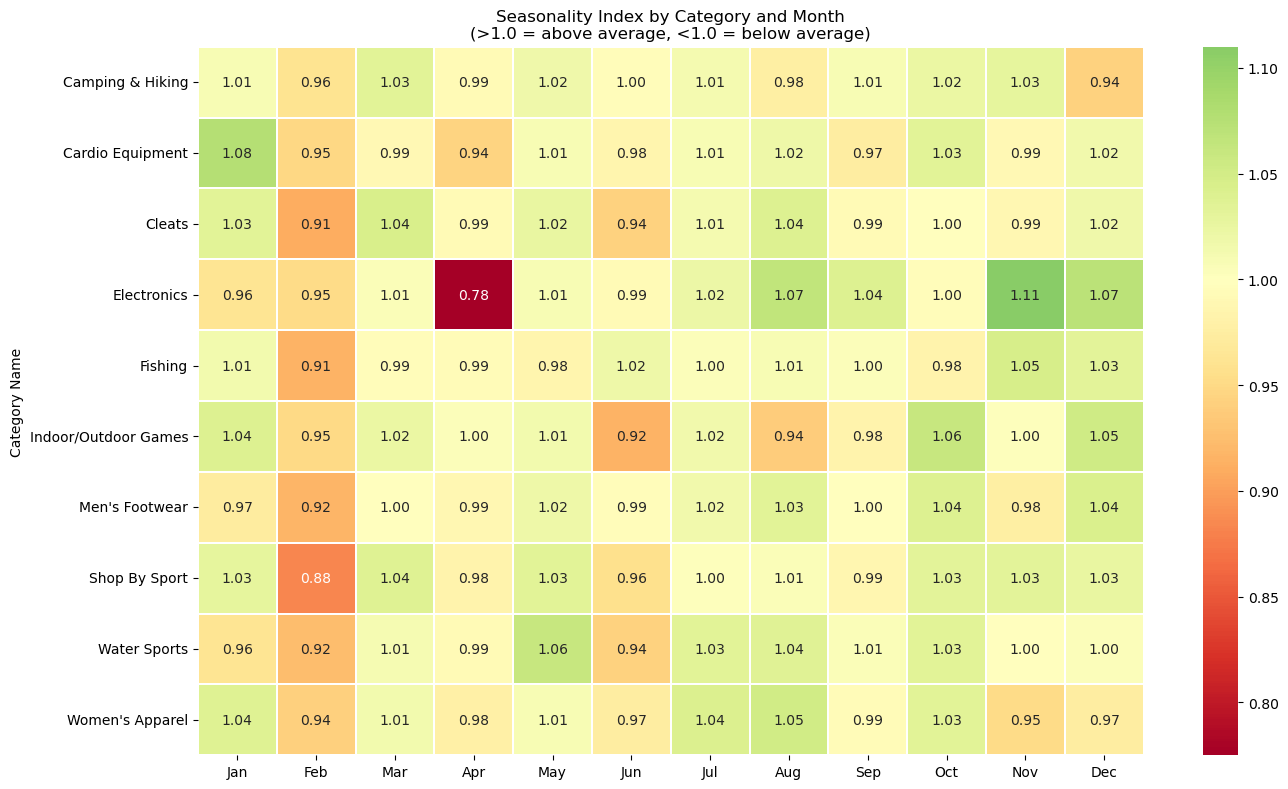

In [20]:
# Seasonality index = monthly avg / overall avg
# > 1.0 means above average month, < 1.0 means below average

seasonality_index = monthly_avg.copy()

# Calculate overall average per category
overall_avg = monthly_avg.groupby('Category Name')['order_count']\
                        .mean().reset_index()
overall_avg.columns = ['Category Name', 'overall_avg']

seasonality_index = seasonality_index.merge(overall_avg, on='Category Name')
seasonality_index['seasonal_index'] = round(
    seasonality_index['order_count'] / seasonality_index['overall_avg'], 3
)

# Pivot for clean display
seasonality_table = seasonality_index.pivot_table(
    index='Category Name',
    columns='order_month',
    values='seasonal_index'
)
seasonality_table.columns = month_labels

# Highlight with heatmap
plt.figure(figsize=(14, 8))
sns.heatmap(
    seasonality_table,
    annot=True,
    fmt='.2f',
    cmap='RdYlGn',
    center=1.0,
    linewidths=0.3
)
plt.title('Seasonality Index by Category and Month\n(>1.0 = above average, <1.0 = below average)')
plt.tight_layout()
plt.show()

# turning point for the project: synthetic data after 1st October 2017

C:\Users\Ali_Elsharkawy\AppData\Local\Temp\ipykernel_6580\456278919.py:16: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_trend = pd.read_sql(query, conn)


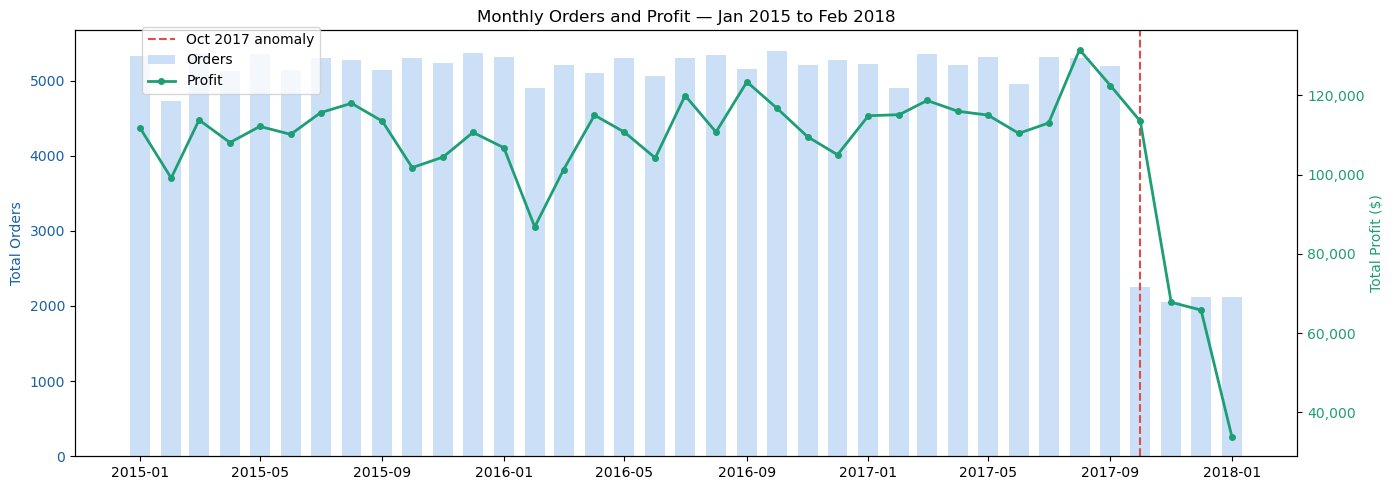

In [ ]:
# total sales across dataco's date scope

query = """
SELECT
    YEAR(order_date_clean)  AS yr,
    MONTH(order_date_clean) AS mo,
    COUNT(*) AS total_orders,
    ROUND(SUM(CAST([Order Profit Per Order] AS FLOAT)), 2) AS total_profit,
    ROUND(SUM(CAST(Sales AS FLOAT)), 2) AS total_sales
FROM dataco_clean
WHERE order_date_clean IS NOT NULL
GROUP BY
    YEAR(order_date_clean),
    MONTH(order_date_clean)
ORDER BY yr, mo;
"""

df_trend = pd.read_sql(query, conn)

# Create a proper date column for the X axis
df_trend['date'] = pd.to_datetime(
    df_trend['yr'].astype(str) + '-' +
    df_trend['mo'].astype(str) + '-01'
)

# Plot
fig, ax1 = plt.subplots(figsize=(14, 5))

# Orders as bars
ax1.bar(df_trend['date'], df_trend['total_orders'],
        width=20, color='#B5D4F4', alpha=0.7, label='Orders')
ax1.set_ylabel('Total Orders', color='#185FA5')
ax1.tick_params(axis='y', labelcolor='#185FA5')

# Profit as line on second axis
ax2 = ax1.twinx()
ax2.plot(df_trend['date'], df_trend['total_profit'],
        color='#1D9E75', linewidth=2,
        marker='o', markersize=4, label='Profit')
ax2.set_ylabel('Total Profit ($)', color='#1D9E75')
ax2.tick_params(axis='y', labelcolor='#1D9E75')

# Mark October 2017
import matplotlib.patches as mpatches
ax1.axvline(
    pd.to_datetime('2017-10-01'),
    color='#E24B4A', linestyle='--',
    linewidth=1.5, label='Oct 2017 anomaly'
)

plt.title('Monthly Orders and Profit — Jan 2015 to Feb 2018')
fig.legend(loc='upper left', bbox_to_anchor=(0.1, 0.95))
plt.tight_layout()
import matplotlib.ticker as mtick
# Format the Profit axis with a thousand separator and zero decimals
ax2.yaxis.set_major_formatter(mtick.StrMethodFormatter('{x:,.0f}'))
plt.show()

# significant profit drop in October-2017 followed by rapid business decay(further focus analysis would be conducted in the main notebook of SQL)

# Post star schema analysis 

In [ ]:
# Pulling the data after cleaning from SQL server
df = pd.read_sql("SELECT * FROM dataco_clean", conn)
df_order = pd.read_sql("SELECT * FROM fact_orders", conn)
df_product = pd.read_sql("SELECT * FROM dim_product", conn)
df_customer = pd.read_sql("SELECT * FROM dim_customer", conn)
df_shipping = pd.read_sql("SELECT * FROM dim_shipping", conn)
df_date = pd.read_sql("SELECT * FROM dim_date", conn)

sales  = pd.to_numeric(df['Sales'], errors='coerce').dropna()
# profit = pd.to_numeric(df['Order Profit Per Order'], errors='coerce').dropna()

print(f"Connected. Rows loaded: {len(df):,}")

C:\Users\Ali_Elsharkawy\AppData\Local\Temp\ipykernel_27220\2889321223.py:12: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql("SELECT * FROM dataco_clean", conn)
C:\Users\Ali_Elsharkawy\AppData\Local\Temp\ipykernel_27220\2889321223.py:13: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_order = pd.read_sql("SELECT * FROM fact_orders", conn)
C:\Users\Ali_Elsharkawy\AppData\Local\Temp\ipykernel_27220\2889321223.py:14: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_product = pd.read_sql("SELECT * FROM dim_produ

Connected. Rows loaded: 180,519


C:\Users\Ali_Elsharkawy\AppData\Local\Temp\ipykernel_27220\2889321223.py:16: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_shipping = pd.read_sql("SELECT * FROM dim_shipping", conn)
C:\Users\Ali_Elsharkawy\AppData\Local\Temp\ipykernel_27220\2889321223.py:17: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_date = pd.read_sql("SELECT * FROM dim_date", conn)


## checking normality for the products sales before calculating SQL safety stock assuming normal distribution

In [ ]:
def analyze_monthly_demand_distribution(df_order, df_product, alpha=0.05):
    # 1. Join Tables
    # We use product_key as the bridge between fact and dim tables
    df_merged = pd.merge(
        df_order,
        df_product,
        on='product_key'
    )

    # Ensure date is datetime and quantity is numeric
    df_merged['order_date_clean'] = pd.to_datetime(df_merged['order_date_clean'])
    df_merged['order_item_quantity'] = pd.to_numeric(df_merged['order_item_quantity'], errors='coerce')

    # 2. Filter for "Mature" products (First sale before 2017)
    first_sales = df_merged.groupby('product_name')['order_date_clean'].min()
    mature_products = first_sales[first_sales < '2017-01-01'].index

    results = []

    # 3. Monthly Aggregation Loop
    for i, name in enumerate(mature_products, 1): # '1' makes the counter start at 1
        product_data = df_merged[df_merged['product_name'] == name]

        # We fill missing months with 0 to account for months with no sales
        monthly_series = product_data.set_index('order_date_clean')['order_item_quantity'] \
                                    .resample('M').sum().fillna(0)

        # 4. Statistical Testing
        # D'Agostino's K^2 needs at least 8 months of data to run
        if len(monthly_series) >= 8:
            # Check for constant demand (no variation)
            if monthly_series.nunique() <= 1:
                p_val = 0.0
            else:
                stat, p = stats.normaltest(monthly_series)
                p_val = round(p, 4) if not np.isnan(p) else 0.0

            results.append({
                'ID': i,
                'Product': name,
                'Months_Analyzed': len(monthly_series),
                'Avg_Monthly_Demand': round(monthly_series.mean(), 2),
                'Monthly_Std_Dev': round(monthly_series.std(), 2),
                'Max_Monthly_Volume': monthly_series.max(),
                'P_Value': p_val,
                'Distribution': 'Normal' if p_val > alpha else 'Non-Normal (Seasonal/Erratic)'
            })

    return pd.DataFrame(results)

# Execute the analysis
df_monthly_report = analyze_monthly_demand_distribution(df_order, df_product)

# Sort to see which products have the most stable, "Normal" monthly patterns
print(df_monthly_report.sort_values(by='ID', ascending=True))

    ID                                        Product  Months_Analyzed  Avg_Monthly_Demand  Monthly_Std_Dev  Max_Monthly_Volume  P_Value                   Distribution
0    1                        Bag Boy Beverage Holder               28               30.18             9.34                  51   0.9976                         Normal
1    2  Bridgestone e6 Straight Distance NFL Carolina               28               33.14            12.15                  58   0.7465                         Normal
2    3  Bridgestone e6 Straight Distance NFL San Dieg               28               32.36             9.03                  58   0.0579                         Normal
3    4  Bridgestone e6 Straight Distance NFL Tennesse               28               28.75            10.97                  53   0.5022                         Normal
4    5                        Clicgear 8.0 Shoe Brush               28               31.71            10.12                  56   0.4406                        

## checking outliers and count of sales before using the average of profit.

Decision: excluding the 2 only products with negative profit for insufficient data (2, 6 sales)
threshold: 30+ sales

In [ ]:
query = """
SELECT
    f.product_key,
    p.product_name,
    p.category_name,
    p.ABC_segment,
    CAST(f.order_item_profit_ratio AS FLOAT) AS profit_ratio
FROM fact_orders f
JOIN dim_product p ON p.product_key = f.product_key
WHERE f.non_revenue_flag = 0
AND f.order_item_profit_ratio IS NOT NULL
AND TRY_CAST(f.order_item_profit_ratio AS FLOAT) IS NOT NULL
"""

df_ratio = pd.read_sql(query, conn)

# Convert to numeric safely
df_ratio['profit_ratio'] = pd.to_numeric(
    df_ratio['profit_ratio'], errors='coerce'
)
df_ratio = df_ratio.dropna(subset=['profit_ratio'])

# IQR analysis per product
def product_iqr_analysis(group):
    ratios = group['profit_ratio']

    Q1  = ratios.quantile(0.25)
    Q3  = ratios.quantile(0.75)
    IQR = Q3 - Q1

    lower_fence = Q1 - 1.5 * IQR
    upper_fence = Q3 + 1.5 * IQR

    outliers = ratios[(ratios < lower_fence) | (ratios > upper_fence)]

    return pd.Series({
        'product_name'      : group['product_name'].iloc[0],
        'category_name'     : group['category_name'].iloc[0],
        'ABC_segment'       : group['ABC_segment'].iloc[0],
        'transaction_count' : len(ratios),
        'mean_ratio'        : round(ratios.mean(), 4),
        'median_ratio'      : round(ratios.median(), 4),
        'std_dev'           : round(ratios.std(), 4),
        'Q1'                : round(Q1, 4),
        'Q3'                : round(Q3, 4),
        'IQR'               : round(IQR, 4),
        'lower_fence'       : round(lower_fence, 4),
        'upper_fence'       : round(upper_fence, 4),
        'outlier_count'     : len(outliers),
        'outlier_pct'       : round(len(outliers) / len(ratios) * 100, 2),
        'min_ratio'         : round(ratios.min(), 4),
        'max_ratio'         : round(ratios.max(), 4),
        # Key diagnostic — is the MEDIAN also negative?
        # If yes → average is not being pulled by outliers
        # If no  → outliers are distorting the average
        'median_is_negative': ratios.median() < 0
    })

# Apply per product
product_analysis = df_ratio.groupby('product_key').apply(
    product_iqr_analysis
).reset_index()

# Sort by outlier count descending
product_analysis = product_analysis.sort_values(
    'outlier_count', ascending=False
)

# Display full results
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 200)
pd.set_option('display.float_format', '{:.4f}'.format)

print("=== Product Profit Ratio IQR Analysis ===")
print(f"Total products analyzed: {len(product_analysis)}")
print()
print(product_analysis[[
    'product_name', 'category_name', 'ABC_segment',
    'transaction_count', 'mean_ratio', 'median_ratio',
    'std_dev', 'Q1', 'Q3', 'IQR',
    'lower_fence', 'upper_fence',
    'outlier_count', 'outlier_pct',
    'median_is_negative'
]].to_string(index=False))

print()
print("=== Products With Negative MEAN Ratio ===")
negative_mean = product_analysis[
    product_analysis['mean_ratio'] < 0
].sort_values('mean_ratio')

print(negative_mean[[
    'product_name', 'category_name', 'transaction_count',
    'mean_ratio', 'median_ratio', 'outlier_count',
    'outlier_pct', 'median_is_negative'
]].to_string(index=False))

print()
print("=== Diagnosis ===")
for _, row in negative_mean.iterrows():
    if row['median_is_negative']:
        diagnosis = "CONFIRMED NEGATIVE — median also negative, not outlier-driven"
    else:
        diagnosis = "INVESTIGATE — median positive, outliers may be distorting average"
    print(f"{row['product_name'][:40]:<40} | mean: {row['mean_ratio']:>8.4f} | "
        f"median: {row['median_ratio']:>8.4f} | {diagnosis}")

C:\Users\Ali_Elsharkawy\AppData\Local\Temp\ipykernel_27220\1208978153.py:15: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_ratio = pd.read_sql(query, conn)


=== Product Profit Ratio IQR Analysis ===
Total products analyzed: 100

                                 product_name        category_name     ABC_segment  transaction_count  mean_ratio  median_ratio  std_dev      Q1      Q3    IQR  lower_fence  upper_fence  outlier_count  outlier_pct  median_is_negative
             Perfect Fitness Perfect Rip Deck               Cleats               A              23441      0.1251        0.2700   0.4568  0.0800  0.3600 0.2800      -0.3400       0.7800           2179       9.3000               False
      Nike Men's CJ Elite 2 TD Football Cleat       Men's Footwear               B              21233      0.1196        0.2700   0.4729  0.0800  0.3600 0.2800      -0.3400       0.7800           2078       9.7900               False
         Nike Men's Dri-FIT Victory Golf Polo      Women's Apparel               A              20089      0.1221        0.2700   0.4652  0.0800  0.3600 0.2800      -0.3400       0.7800           1916       9.5400             

## profit ratio for product over 30 sales 

Confirmed: losses are more likely operational not product stricture issue. 

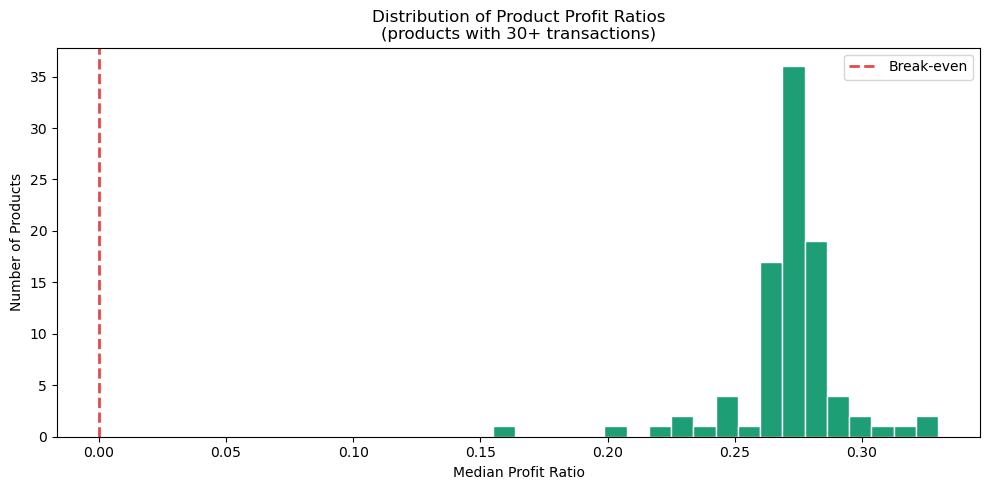

In [5]:
plt.figure(figsize=(10, 5))
plt.hist(
    product_analysis[product_analysis['transaction_count'] >= 30]['median_ratio'],
    bins=20,
    color='#1D9E75',
    edgecolor='white'
)
plt.axvline(x=0, color='#E24B4A', linestyle='--', linewidth=2, label='Break-even')
plt.title('Distribution of Product Profit Ratios\n(products with 30+ transactions)')
plt.xlabel('Median Profit Ratio')
plt.ylabel('Number of Products')
plt.legend()
plt.tight_layout()
plt.show()